In [386]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [387]:
df = pd.read_csv('netflix_titles.csv')

In [388]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [389]:
df.shape # containing 8807 rows and 12 columns

(8807, 12)

In [390]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [391]:
df.sample()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1873,s1874,TV Show,The Haunting of Bly Manor,NaN,"Victoria Pedretti, Oliver Jackson-Cohen, Henry...",United States,"October 9, 2020",2020,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",Dead doesn't mean gone. An au pair plunges int...


In [392]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [393]:
# category => ['type', rating, ]
df[['type','rating']] = df[['type','rating']].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       8807 non-null   object  
 1   type          8807 non-null   category
 2   title         8807 non-null   object  
 3   director      6173 non-null   object  
 4   cast          7982 non-null   object  
 5   country       7976 non-null   object  
 6   date_added    8797 non-null   object  
 7   release_year  8807 non-null   int64   
 8   rating        8803 non-null   category
 9   duration      8804 non-null   object  
 10  listed_in     8807 non-null   object  
 11  description   8807 non-null   object  
dtypes: category(2), int64(1), object(9)
memory usage: 706.2+ KB


In [394]:
df['show_id'].nunique

<bound method IndexOpsMixin.nunique of 0          s1
1          s2
2          s3
3          s4
4          s5
        ...  
8802    s8803
8803    s8804
8804    s8805
8805    s8806
8806    s8807
Name: show_id, Length: 8807, dtype: object>

In [395]:
# setting show)id as default index
df.set_index('show_id',inplace = True)

In [396]:
print(df['date_added'].isnull().sum())
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])

10


In [397]:
df.describe()

,date_added,release_year
count,8797,8807.000000
mean,2019-05-17 05:59:08.436967168,2014.180198
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-02 00:00:00,2017.000000
75%,2020-08-19 00:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.819312


In [398]:
df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [399]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [400]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
UR             3
NC-17          3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [401]:
df[['director', 'cast', 'country']] = df[['director', 'cast', 'country']].fillna('Unknown')

In [402]:
df.dropna(inplace = True) # droping null values because few null values left

In [403]:
df.isnull().sum()

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [404]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, s1 to s8807
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          8790 non-null   category      
 1   title         8790 non-null   object        
 2   director      8790 non-null   object        
 3   cast          8790 non-null   object        
 4   country       8790 non-null   object        
 5   date_added    8790 non-null   datetime64[ns]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   category      
 8   duration      8790 non-null   object        
 9   listed_in     8790 non-null   object        
 10  description   8790 non-null   object        
dtypes: category(2), datetime64[ns](1), int64(1), object(7)
memory usage: 704.7+ KB


In [405]:
df.sample(2)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
show_id,,,,,,,,,,,
s7725,Movie,Penelope,Mark Palansky,"Christina Ricci, James McAvoy, Catherine O'Har...","United Kingdom, United States",2019-04-01,2006,PG,89 min,"Children & Family Movies, Comedies, Romantic M...","In this modern fairy tale, a young woman curse..."
s3403,Movie,"Love, Surreal and Odd",Yılmaz Erdoğan,"Aylin Kontante, Bülent Emrah Parlak, Büşra Pek...",Turkey,2019-10-18,2017,TV-14,95 min,"Comedies, International Movies, Romantic Movies",When a group of people meets at the same party...


NOTE : Not all datasets require duplicate removal and not all duplicates are row-level duplicates

Text(0, 0.5, 'Number of Movies')

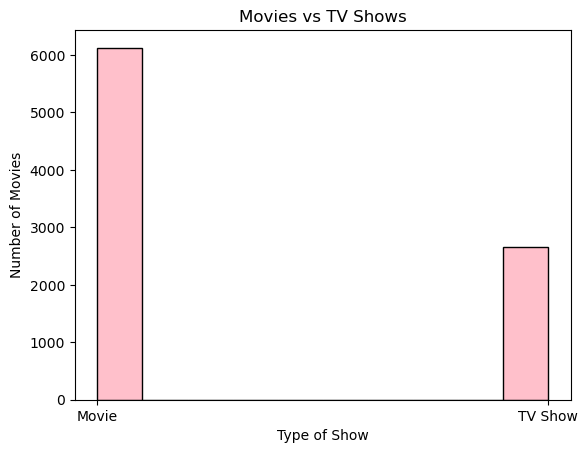

In [406]:
#What is the percentage distribution of Movies vs TV Shows on Netflix?
plt.hist(df['type'], edgecolor = 'black', color = 'pink')
plt.title('Movies vs TV Shows')
plt.xlabel('Type of Show')
plt.ylabel('Number of Movies')

In [407]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [408]:
# Which countries have produced the highest number of Netflix titles? => US produces 2809 movies 
df.groupby('country')['type'].count().sort_values(ascending = False).head()

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
Name: type, dtype: int64

In [409]:
# Which directors have contributed the highest number of titles on Netflix?
df[df['director'] != 'Unknown']
df[df['director'] != 'Unknown']['director'].value_counts().head()

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Name: count, dtype: int64

In [410]:
#In which year was the maximum content added to Netflix?
df.groupby('release_year')['title'].count().sort_values(ascending = False).head(10)

release_year
2018    1146
2019    1030
2017    1030
2020     953
2016     901
2021     592
2015     555
2014     352
2013     286
2012     236
Name: title, dtype: int64

In [411]:
# Which rating category has the highest number of titles on Netflix?
df.groupby(['rating','type'])['title'].count().sort_values(ascending = False).head()

/tmp/ipykernel_4758/721674781.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['rating','type'])['title'].count().sort_values(ascending = False).head()


rating  type   
TV-MA   Movie      2062
TV-14   Movie      1427
TV-MA   TV Show    1143
R       Movie       797
TV-14   TV Show     730
Name: title, dtype: int64

In [412]:
df['type'].value_counts() / df.shape[0] * 100

type
Movie      69.692833
TV Show    30.307167
Name: count, dtype: float64

In [413]:
df['year_added'] = df['date_added'].dt.year
df.groupby(['year_added', 'type']).size().sort_values(ascending = False)

/tmp/ipykernel_4758/2660561761.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['year_added', 'type']).size().sort_values(ascending = False)


year_added  type   
2019        Movie      1424
2020        Movie      1284
2018        Movie      1237
2021        Movie       993
2017        Movie       836
2020        TV Show     595
2019        TV Show     592
2021        TV Show     505
2018        TV Show     411
2017        TV Show     349
2016        Movie       251
            TV Show     175
2015        Movie        56
            TV Show      26
2014        Movie        19
2011        Movie        13
2013        Movie         6
2014        TV Show       5
2013        TV Show       5
2012        Movie         3
2009        Movie         2
2008        TV Show       1
2010        Movie         1
2008        Movie         1
2012        TV Show       0
2011        TV Show       0
2010        TV Show       0
2009        TV Show       0
dtype: int64

In [414]:
# How are Movies and TV Shows distributed across different rating categories?
df.groupby(['rating', 'type']).size().sort_values(ascending=False)

/tmp/ipykernel_4758/1358406002.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['rating', 'type']).size().sort_values(ascending=False)


rating    type   
TV-MA     Movie      2062
TV-14     Movie      1427
TV-MA     TV Show    1143
R         Movie       797
TV-14     TV Show     730
TV-PG     Movie       540
PG-13     Movie       490
TV-PG     TV Show     321
PG        Movie       287
TV-Y7     TV Show     194
TV-Y      TV Show     175
TV-Y7     Movie       139
TV-Y      Movie       131
TV-G      Movie       126
          TV Show      94
NR        Movie        75
G         Movie        41
TV-Y7-FV  Movie         5
NR        TV Show       4
NC-17     Movie         3
UR        Movie         3
R         TV Show       2
TV-Y7-FV  TV Show       1
66 min    Movie         0
          TV Show       0
PG-13     TV Show       0
PG        TV Show       0
NC-17     TV Show       0
G         TV Show       0
84 min    TV Show       0
          Movie         0
74 min    TV Show       0
          Movie         0
UR        TV Show       0
dtype: int64

/tmp/ipykernel_4758/864896571.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['rating', 'type']).size().unstack().plot(kind = 'bar')


<Axes: xlabel='rating'>

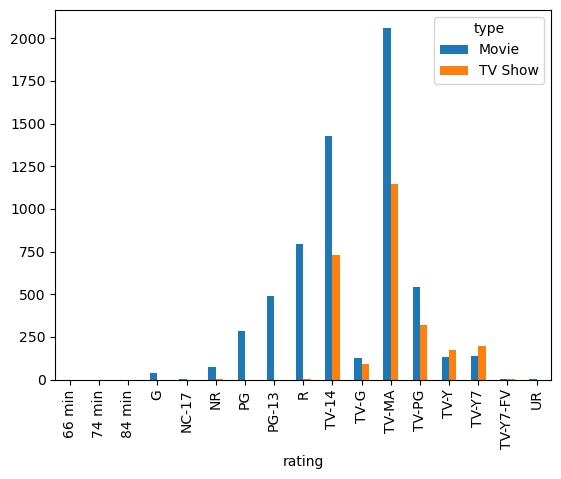

In [415]:
df.groupby(['rating', 'type']).size().unstack().plot(kind = 'bar')

In [416]:
# What are the longest movies (in minutes) and longest TV shows (in seasons)?
df.sample(5)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
show_id,,,,,,,,,,,,
s3141,Movie,Isoken,Jadesola Osiberu,"Dakore Akande, Joseph Benjamin, Marc Rhys, Fun...",Nigeria,2019-12-15,2017,TV-14,98 min,"Comedies, International Movies, Romantic Movies","Single at 34, Isoken is maneuvered by her moth...",2019
s1150,TV Show,Yu-Gi-Oh!,Unknown,"Dan Green, Eric Stuart, Amy Birnbaum, Darren D...",Japan,2021-03-31,2005,TV-Y7,1 Season,"Anime Series, Kids' TV",The lives of young Yugi Moto and his friends J...,2021
s8755,Movie,Wolves,Bart Freundlich,"Michael Shannon, Carla Gugino, Taylor John Smi...",United States,2019-03-29,2016,R,109 min,"Dramas, Independent Movies, Sports Movies",A promising high school basketball player has ...,2019
s8504,TV Show,The Seventies,Unknown,Unknown,United States,2018-09-30,2015,TV-PG,1 Season,Docuseries,"This series examines 1970s America, focusing o...",2018
s108,Movie,A Champion Heart,David de Vos,"Mandy Grace, David de Vos, Donna Rusch, Devan ...",United States,2021-09-04,2018,G,90 min,"Children & Family Movies, Dramas",When a grieving teen must work off her debt to...,2021


In [417]:
df[['duration_value', 'duration_type']] = df['duration'].str.split(' ', expand=True)

In [418]:
df[df['duration_type'] == 'min']['duration_value'].astype(int).max()

312

In [419]:
df[df['duration_type'].str.contains('Season')]['duration_value'].astype(int).max()

17

In [420]:
df[df['duration'] == "312 min"]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_value,duration_type
show_id,,,,,,,,,,,,,,
s4254,Movie,Black Mirror: Bandersnatch,Unknown,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",2018,312,min


In [421]:
df[df['duration'] == "17 Seasons"]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_value,duration_type
show_id,,,,,,,,,,,,,,
s549,TV Show,Grey's Anatomy,Unknown,"Ellen Pompeo, Sandra Oh, Katherine Heigl, Just...",United States,2021-07-03,2020,TV-14,17 Seasons,"Romantic TV Shows, TV Dramas",Intern (and eventual resident) Meredith Grey f...,2021,17,Seasons


In [422]:
df[df['country'] != 'Unknown'].groupby(['country','type']).size().sort_values(ascending = False).head(10)

/tmp/ipykernel_4758/4247027238.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['country'] != 'Unknown'].groupby(['country','type']).size().sort_values(ascending = False).head(10)


country         type   
United States   Movie      2055
India           Movie       893
United States   TV Show     754
United Kingdom  TV Show     212
                Movie       206
Japan           TV Show     167
South Korea     TV Show     158
Canada          Movie       122
Spain           Movie        97
Egypt           Movie        92
dtype: int64

In [423]:
"""What is the trend of content addition over months? (Seasonality Analysis) 
(Are there specific months where Netflix adds more content?)"""

df['month'] = df['date_added'].dt.month
df.groupby('month')['title'].count()

month
1     737
2     562
3     741
4     763
5     632
6     728
7     827
8     754
9     769
10    760
11    705
12    812
Name: title, dtype: int64

In [424]:
# Which genres are most common on Netflix, and how do they differ between Movies and TV Shows? 
df.sample(5)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_value,duration_type,month
show_id,,,,,,,,,,,,,,,
s3627,Movie,Misfit,Erwin van den Eshof,"Djamila, Niek Roozen, Bente Fokkens, Jolijn He...",Netherlands,2019-08-03,2017,TV-14,81 min,"Children & Family Movies, Comedies, Internatio...","After living in America for years, a teenage g...",2019,81,min,8
s2071,TV Show,Heidi,Unknown,"Monique Hore, Sophia Morrison, Peter McAllum, ...","France, Australia, Germany",2020-09-01,2020,TV-Y7,1 Season,Kids' TV,A plucky young orphan sent to live with her gr...,2020,1,Season,9
s2771,Movie,True: Wuzzle Wegg Day,"Todd Kauffman, Mark Thornton","Michela Luci, Jamie Watson, Eric Peterson, Ann...",Canada,2020-03-27,2020,TV-Y,24 min,Children & Family Movies,"Spring has sprung in Rainbow City, and Wuzzle ...",2020,24,min,3
s667,TV Show,Gameboys Level-Up Edition,Ivan Andrew Payawal,"Kokoy De Santos, Elijah Canlas, Adrianna So, K...",Unknown,2021-06-19,2020,TV-14,1 Season,"International TV Shows, Romantic TV Shows, TV ...","In this recut of the popular web series, live-...",2021,1,Season,6
s2644,TV Show,Love 101,Unknown,"Pınar Deniz, Kubilay Aka, Mert Yazıcıoğlu, Ali...",Turkey,2020-04-24,2020,TV-MA,1 Season,"International TV Shows, TV Dramas, Teen TV Shows",While trying to make their teacher fall for a ...,2020,1,Season,4


In [425]:
df['listed_in'].head()

show_id
s1                                        Documentaries
s2      International TV Shows, TV Dramas, TV Mysteries
s3    Crime TV Shows, International TV Shows, TV Act...
s4                               Docuseries, Reality TV
s5    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [426]:
temp_df = df.copy()

In [427]:
temp_df['listed_in'] = temp_df['listed_in'].str.split(',')

In [428]:
temp_df = temp_df.explode('listed_in')

In [429]:
temp_df['listed_in'] = temp_df['listed_in'].str.strip()

In [430]:
temp_df.groupby(['listed_in','type']).size().sort_values(ascending = False).head(20)

/tmp/ipykernel_4758/3280242943.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_df.groupby(['listed_in','type']).size().sort_values(ascending = False).head(20)


listed_in                 type   
International Movies      Movie      2752
Dramas                    Movie      2426
Comedies                  Movie      1674
International TV Shows    TV Show    1349
Documentaries             Movie       869
Action & Adventure        Movie       859
TV Dramas                 TV Show     762
Independent Movies        Movie       756
Children & Family Movies  Movie       641
Romantic Movies           Movie       616
Thrillers                 Movie       577
TV Comedies               TV Show     573
Crime TV Shows            TV Show     469
Kids' TV                  TV Show     448
Docuseries                TV Show     394
Music & Musicals          Movie       375
Romantic TV Shows         TV Show     370
Horror Movies             Movie       357
Stand-Up Comedy           Movie       343
Reality TV                TV Show     255
dtype: int64

In [431]:
# Which countries produce more diverse genres of content?
temp_df[temp_df['country'] != 'Unknown'] .groupby('country')['listed_in'] .nunique() .sort_values(ascending=False).head(10)

country
United States     42
India             35
Canada            35
United Kingdom    34
Australia         31
Spain             30
Japan             29
France            28
Mexico            28
Argentina         28
Name: listed_in, dtype: int64

In [432]:
# Split and explode country column
temp_df['country'] = temp_df['country'].str.split(', ')
temp_df = temp_df.explode('country')

# Clean country values
temp_df['country'] = temp_df['country'].str.strip()

# Convert duration to numeric
temp_df['duration_value'] = temp_df['duration_value'].astype(int)

# Filter only Movies (duration in minutes)
movies_df = temp_df[temp_df['duration_type'] == 'min']

# Count number of movies per country
country_counts = movies_df.groupby('country')['duration_value'].count()

# Keep only countries with sufficient data (>= 10 movies)
valid_countries = country_counts[country_counts >= 10].index

# Calculate average duration for valid countries
avg_duration = movies_df[movies_df['country'].isin(valid_countries)].groupby('country')['duration_value'].mean().sort_values(ascending=False)

# Show top 10 countries
avg_duration.head(5)

country
Morocco     135.333333
India       127.067536
Pakistan    124.462963
Romania     119.250000
Hungary     113.450000
Name: duration_value, dtype: float64

In [433]:
# How has the average movie duration changed over time?
movies_df['duration_value'].mean()

103.91320844202039

In [434]:
# Which rating categories are most common within each genre?
temp_df['listed_in'].value_counts()

listed_in
International Movies            3509
Dramas                          3198
Comedies                        1981
International TV Shows          1463
Action & Adventure              1182
Documentaries                   1116
Independent Movies              1040
TV Dramas                        851
Children & Family Movies         845
Thrillers                        806
Romantic Movies                  722
TV Comedies                      622
Kids' TV                         593
Crime TV Shows                   540
Horror Movies                    458
Docuseries                       435
Music & Musicals                 429
Romantic TV Shows                384
Sci-Fi & Fantasy                 380
Stand-Up Comedy                  344
British TV Shows                 305
Reality TV                       270
Sports Movies                    265
TV Action & Adventure            203
Spanish-Language TV Shows        201
Anime Series                     190
Korean TV Shows             

In [435]:
temp_df.groupby('listed_in')['rating'].value_counts().unstack().idxmax(axis=1)

listed_in
Action & Adventure                  R
Anime Features                  TV-14
Anime Series                    TV-14
British TV Shows                TV-MA
Children & Family Movies           PG
Classic & Cult TV               TV-14
Classic Movies                      R
Comedies                        TV-14
Crime TV Shows                  TV-MA
Cult Movies                         R
Documentaries                   TV-MA
Docuseries                      TV-MA
Dramas                          TV-MA
Faith & Spirituality            TV-14
Horror Movies                   TV-MA
Independent Movies              TV-MA
International Movies            TV-MA
International TV Shows          TV-MA
Kids' TV                        TV-Y7
Korean TV Shows                 TV-14
LGBTQ Movies                    TV-MA
Movies                          TV-PG
Music & Musicals                TV-MA
Reality TV                      TV-MA
Romantic Movies                 TV-14
Romantic TV Shows               TV-14
Sc

In [436]:
# Which actors appear most frequently in Netflix content?
temp_df = temp_df[temp_df['cast'] != 'Unknown']
temp_df['cast'] = temp_df['cast'].str.split(',')
temp_df = temp_df.explode('cast')

In [437]:
temp_df['cast'].value_counts().sort_values(ascending = False).head(1)

cast
Anupam Kher    116
Name: count, dtype: int64

In [458]:
content_age = df['date_added'].dt.year - df['release_year']
content_age = content_age[content_age >= 0]
content_age

show_id
s1        1
s2        0
s3        0
s4        0
s5        0
         ..
s8803    12
s8804     1
s8805    10
s8806    14
s8807     4
Length: 8776, dtype: int64

In [461]:
# What is the relationship between release year and date added?
content_age.max()

93

In [462]:
content_age.min()

0

(array([7.436e+03, 7.690e+02, 2.890e+02, 1.330e+02, 8.600e+01, 2.700e+01,
        1.800e+01, 1.400e+01, 3.000e+00, 1.000e+00]),
 array([ 0. ,  9.3, 18.6, 27.9, 37.2, 46.5, 55.8, 65.1, 74.4, 83.7, 93. ]),
 <BarContainer object of 10 artists>)

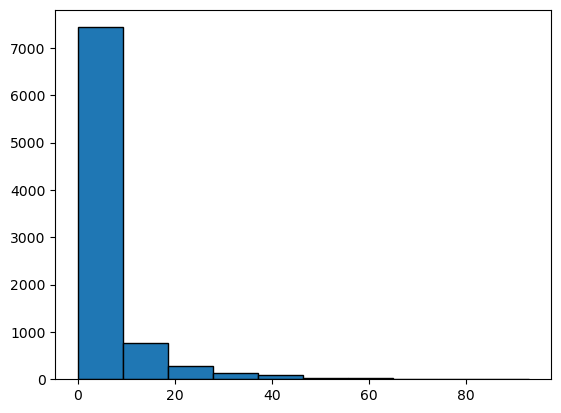

In [468]:
plt.hist(content_age, bins = 10, edgecolor = 'black')

In [2]:
# Insights

"""
1.Movies dominate Netflix’s content, making up around 70% of the total, while TV Shows account for about 30%.
2.The United States contributes the highest number of titles, followed by India, indicating strong global participation.
3.Most directors appear only once, showing that Netflix content is highly diverse and not dominated by a few creators.
4.Content addition increased rapidly after 2016, with peak growth between 2018 and 2020.
5.The majority of content is rated TV-MA and TV-14, indicating a focus on mature and teenage audiences.
6.Top categories include International Movies, Dramas, and Comedies, highlighting Netflix’s global and genre-diverse strategy.
7.Movies span a wide variety of genres, while TV Shows are more structured into categories like TV Dramas and TV Comedies.
8.Countries like the United States and India exhibit high genre diversity, producing content across multiple categories.
9.The average movie duration is approximately 104 minutes, aligning with standard viewing preferences.
10.Countries such as India and Pakistan tend to produce longer movies, reflecting regional storytelling styles.
11.Actors like Anupam Kher appear most frequently, indicating a strong presence of Indian cinema on Netflix.
12.Content is added consistently throughout the year, with slight peaks in July and December and a dip in February.
13.Most Netflix content is added within 0–5 years of release, showing a strong focus on recent content while maintaining some older titles.
14.Overall, Netflix follows a balanced strategy by focusing on movies for volume, TV Shows for engagement, and expanding globally with diverse and recent content.
"""

'\n1.Movies dominate Netflix’s content, making up around 70% of the total, while TV Shows account for about 30%.\n2.The United States contributes the highest number of titles, followed by India, indicating strong global participation.\n3.Most directors appear only once, showing that Netflix content is highly diverse and not dominated by a few creators.\n4.Content addition increased rapidly after 2016, with peak growth between 2018 and 2020.\n5.The majority of content is rated TV-MA and TV-14, indicating a focus on mature and teenage audiences.\n6.Top categories include International Movies, Dramas, and Comedies, highlighting Netflix’s global and genre-diverse strategy.\n7.Movies span a wide variety of genres, while TV Shows are more structured into categories like TV Dramas and TV Comedies.\n8.Countries like the United States and India exhibit high genre diversity, producing content across multiple categories.\n9.The average movie duration is approximately 104 minutes, aligning with st